In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from engine.noise import fbm
from engine.heightmap import normalize

In [ ]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

terrain_cfg = config["terrain"]
render_cfg = config["render"]

In [ ]:
hm = fbm(
    terrain_cfg["width"],
    terrain_cfg["height"],
    scale=terrain_cfg["scale"],
    octaves=terrain_cfg.get("octaves", 4),
    seed=terrain_cfg.get("seed", None)
)
hm = normalize(hm)

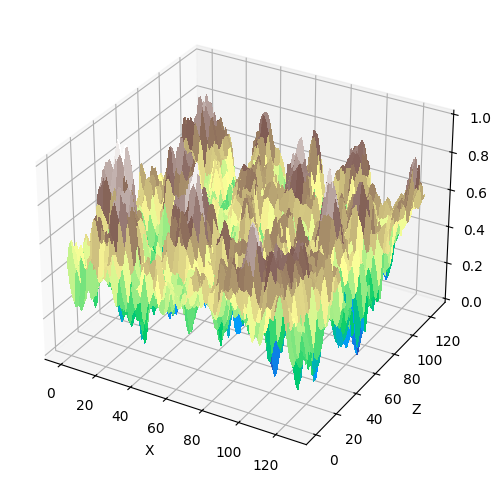

In [5]:
fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection="3d")
X, Y = np.meshgrid(range(terrain_cfg["width"]), range(terrain_cfg["height"]))
ax.plot_surface(X, Y, hm, cmap=render_cfg.get("cmap", "terrain"), linewidth=0, antialiased=False)

ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
plt.show()